# Hybrid TPU + GDDR6-AiM Evaluation

This notebook evaluates an LLM workload on a hybrid architecture that combines a
TPU-style systolic array with a GDDR6-AiM (Accelerator-in-Memory) processing-in-memory
system. A `Fork` in the architecture lets the mapper assign each einsum to whichever
compute path is more efficient:

- **TPU path**: 128x128 systolic array with 128 MB global buffer (compute-bound ops)
- **AiM path**: 512 independent PUs with 32 GB/s per-bank DRAM (memory-bound ops)

## Setup

In [61]:
from pathlib import Path
import accelforge as af

examples_dir = Path("../examples")

HYBRID_ARCH = examples_dir / "arches" / "tpu_aim_hybrid.yaml"
WORKLOAD = examples_dir / "workloads" / "gpt3_small_hybrid.yaml"

BATCH_SIZE = 1
N_TOKENS = 1  # Decode phase: 1 token at a time

spec = af.Spec.from_yaml(
    HYBRID_ARCH,
    WORKLOAD,
    jinja_parse_data={"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS},
)

## Architecture

The hybrid architecture uses a `Fork` to split into two compute paths from shared
HBM main memory. The TPU path has a deep memory hierarchy (GlobalBuffer, LocalBuffer,
Register) feeding a 128x128 systolic array. The AiM path has 512 independent
processing units, each with its own 32 GB/s DRAM bank and 2 KB global buffer.

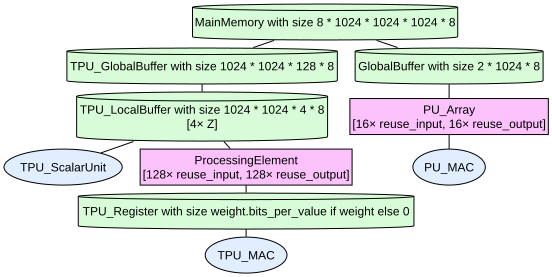

In [62]:
spec.arch

## Workload

GPT-3-like transformer with small ranks for fast mapper evaluation. Includes QKV
projections, attention (QK, softmax, AV), output projection, and FFN layers.
Rank ratios match GPT-3 6.7B scaled down by 64x.

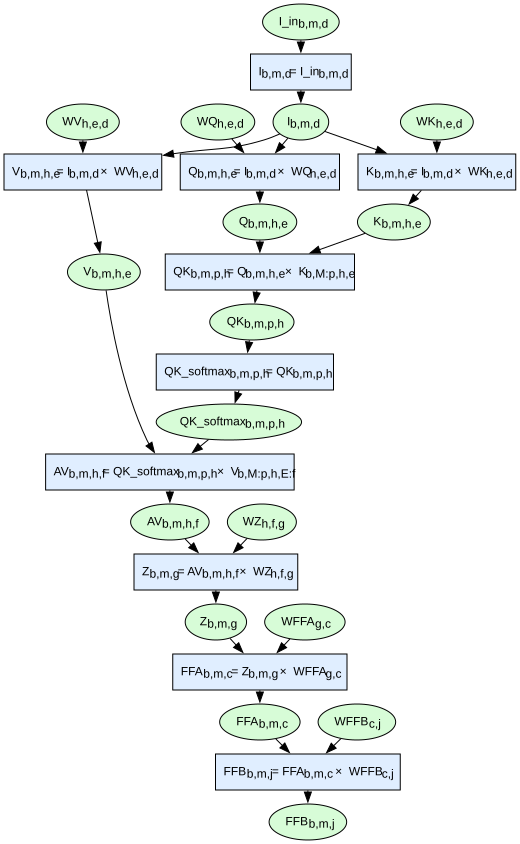

In [63]:
spec.workload

## Map Workload to Architecture

We map the full workload in a single call. The mapper jointly optimizes across all
einsums and automatically assigns each to the TPU or AiM path through the Fork.
















Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 10/10 [00:02<00:00,  3.84it/s]





Generating pmapping templates for compute TPU_ScalarUnit Einsum I: 2it [00:00, 164.30it/s]
Generating pmapping templates for compute TPU_MAC Einsum I: 0it [00:00, ?it/s]
Generating pmapping templates for compute PU_MAC Einsum I: 3it [00:00, 307.35it/s]/s]0, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum V: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum K: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Q: 0it [00:00, ?it/s]s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum QK: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Z: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum AV: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum FFA: 

Einsum I has 5 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	2	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	3	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	4	[I_in in MainMemory] T-b  T-d  T-m  [I_in in GlobalBuffer] [I in GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
Einsum V has 116 pmapping jobs:
	0	[WV in MainMemory] T-b  T-m  [I in TPU_GlobalBuffer] T-b  T-e  T-h  T-m  [V in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I in TPU_LocalBuffer] T-e  T-h  [V in TPU_LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [W

Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal












Dirty pruning pmappings: 100%|██████████| 208/208 [00:00<00:00, 1313.13it/s]


Dirty joining uses 32.51% of the pmappings


...











Dirty pruning pmappings: 100%|██████████| 208/208 [00:00<00:00, 1769.46it/s]


Dirty joining uses 99.95% of the pmappings
Filtered 2189 -> 2189 (100.00% kept) pmappings







Joining pmappings for I <--> V (2/10): 100%|██████████| 11/11 [00:00<00:00, 186.66it/s]










Grouping pmappings: 100%|██████████| 1/1 [00:00<00:00, 151.93it/s]















Joining pmappings for K <--> Q (4/10): 100%|██████████| 137/137 [00:00<00:00, 435.67it/s]





Grouping pmappings: 100%|██████████| 43/43 [00:00<00:00, 519.32it/s]

























Joining pmappings for Q <--> QK (5/10): 100%|██████████| 210/210 [00:00<00:00, 426.33it/s]





Grouping pmappings: 100%|██████████| 13/13 [00:00<00:00, 180.46it/s]





Joining pmappings for QK <--> QK_softmax (6/10): 100%|██████████| 29/29 [00:00<00:00, 366.08it/s]





Grouping pmappings: 100%|██████████| 9/9 [00:00<00:00, 230.57it/s]





Joining pmappings for QK_softmax <--> AV (7/10): 100%|██████████| 28/28 [00:00<00:00, 355.76it/s]





Grouping pmappings: 100%|██████████| 4/4 [00:00<00:00, 166.57it/s]





Joining pmappings for AV <--> Z (8/10): 100%|██████████| 11/11 [00:00<00:00, 208.83it/s]





Grouping pma

Dirty joining mapping(s) valid & optimal! Returning...







/Users/erik/Downloads/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:348: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [
/Users/erik/Downloads/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:348: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [





/Users/erik/Downloads/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:348: PerformanceWarning: DataFrame is highly fragmented.  Thi

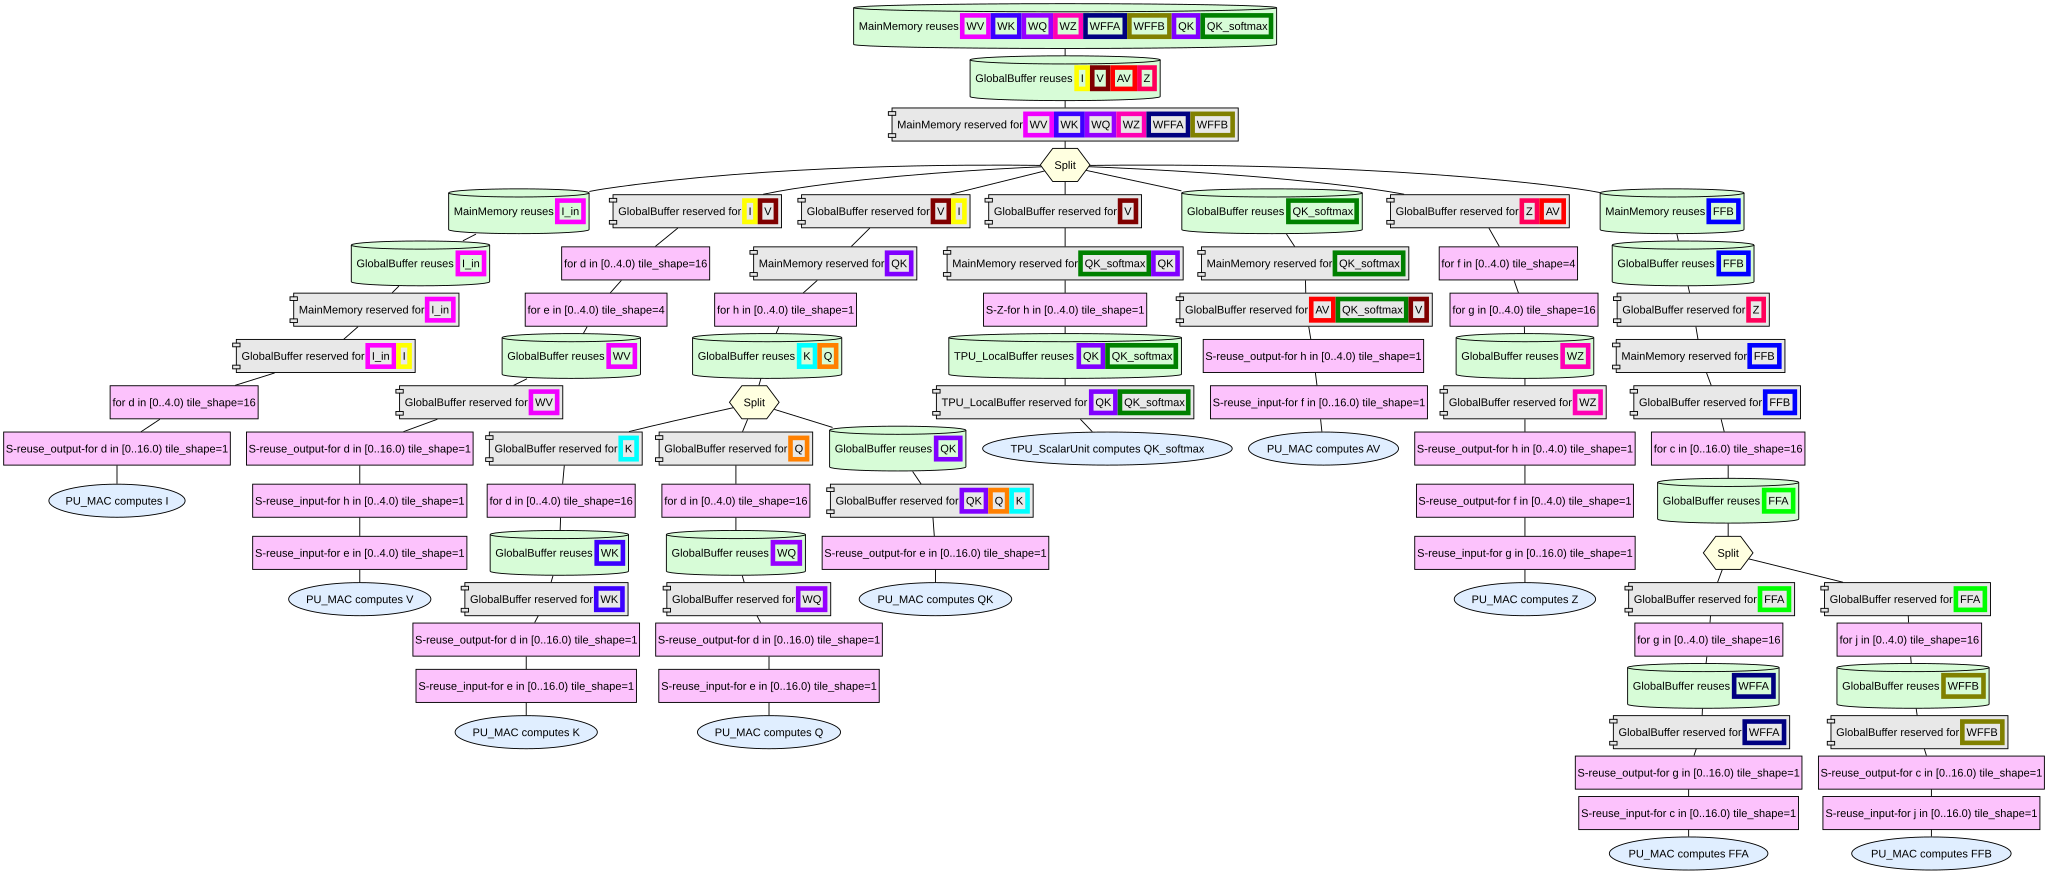

In [64]:
spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
mapping = spec.map_workload_to_arch()
mapping[0].render()

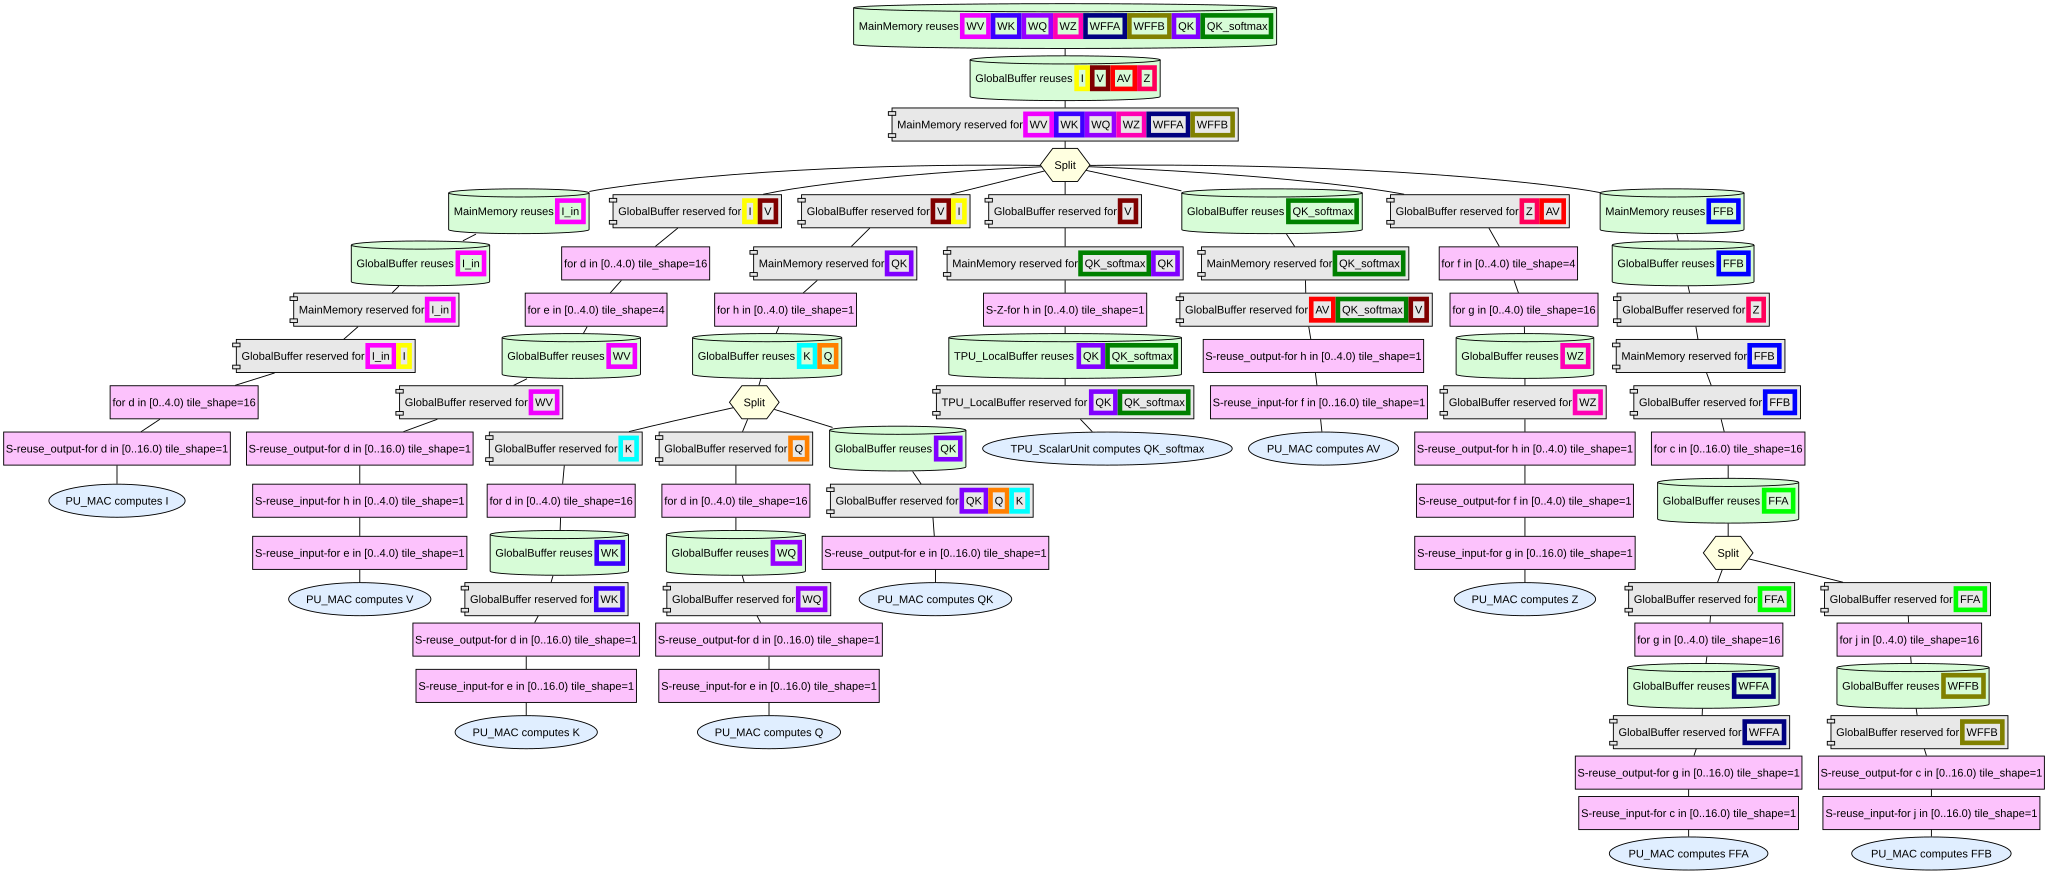

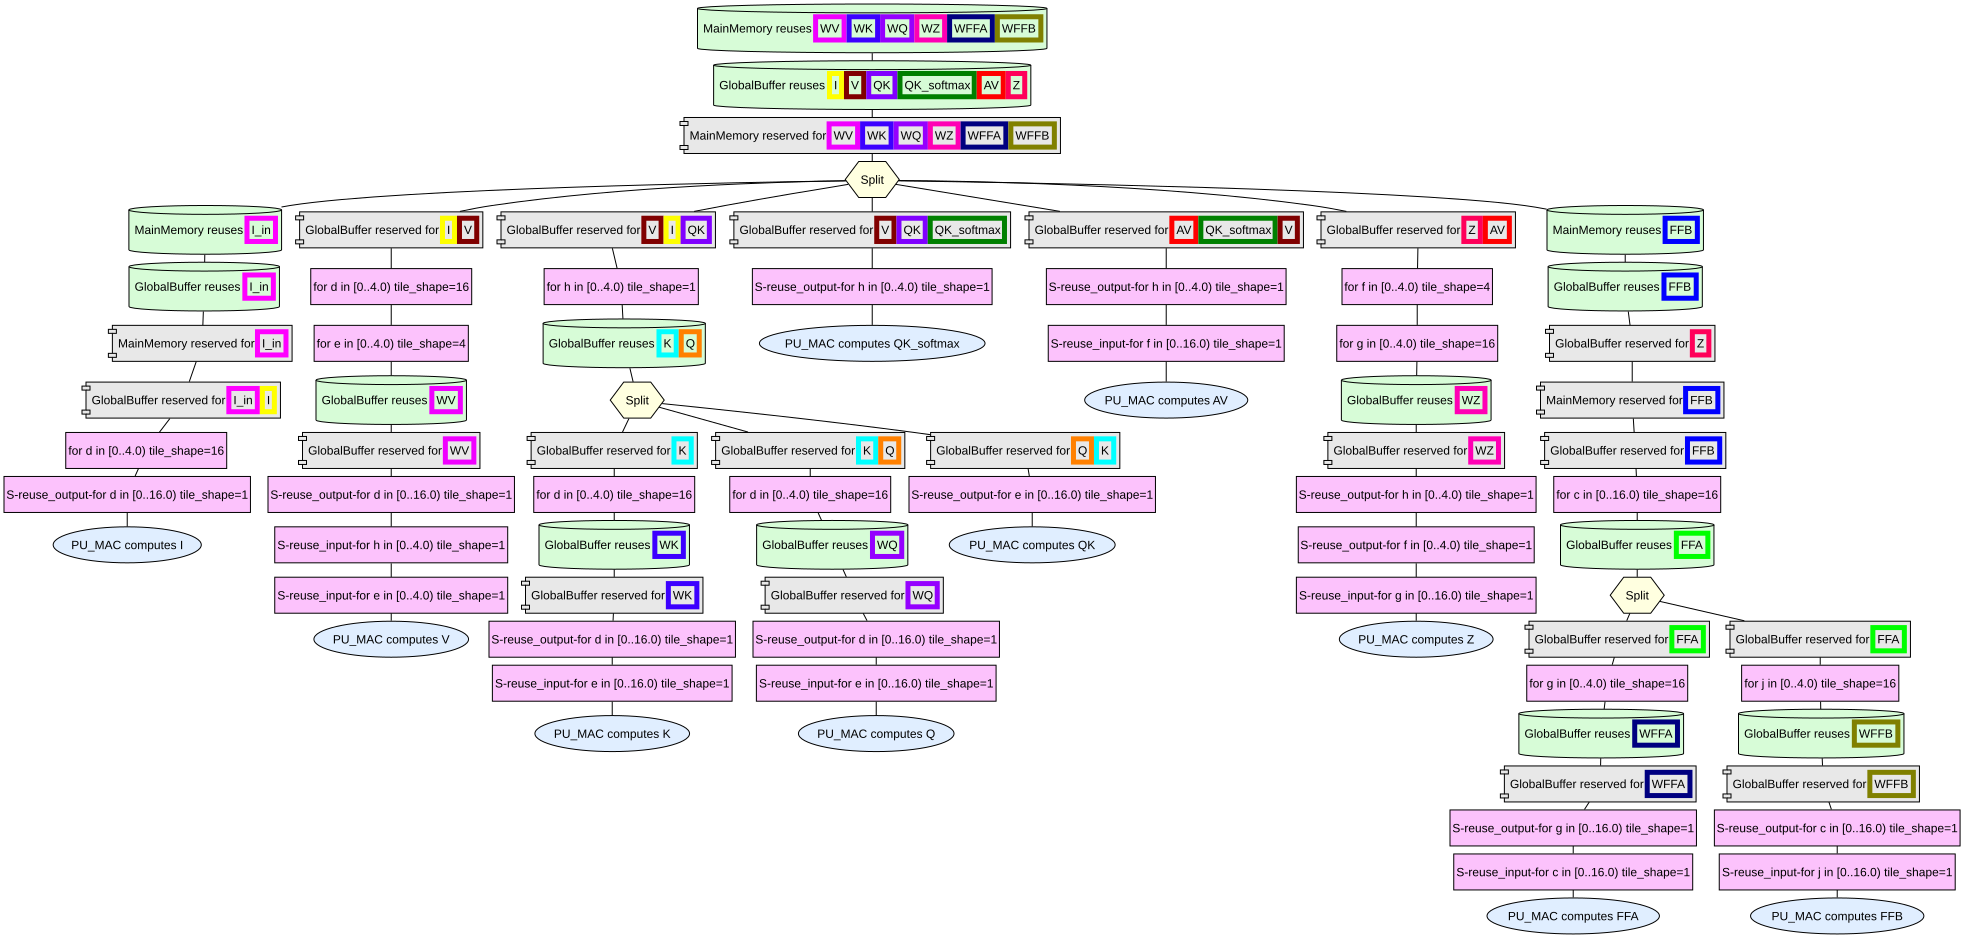

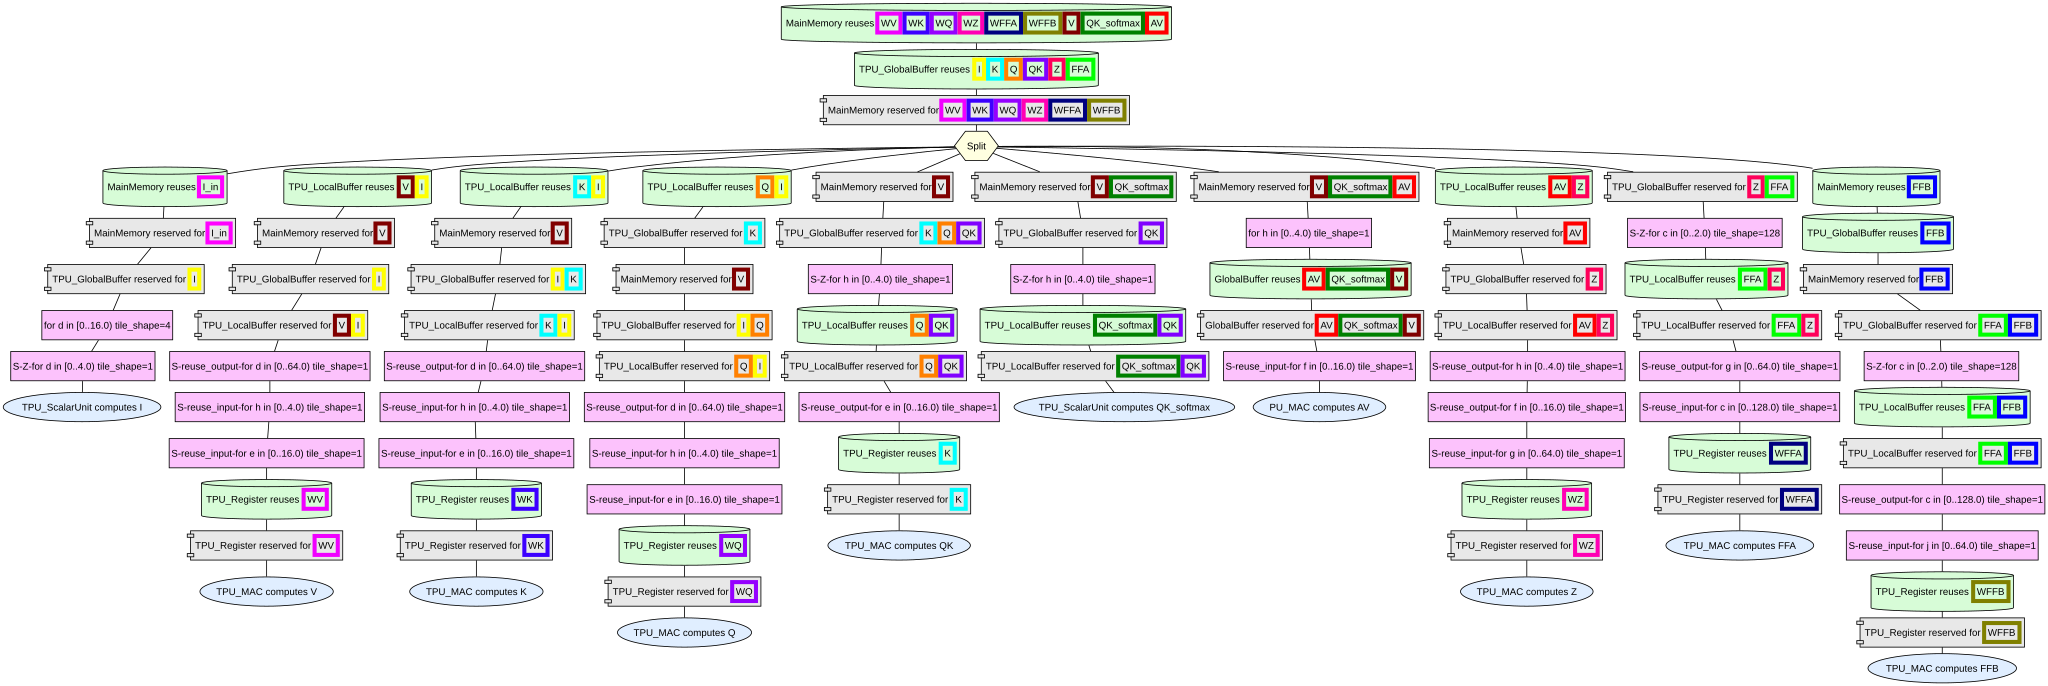

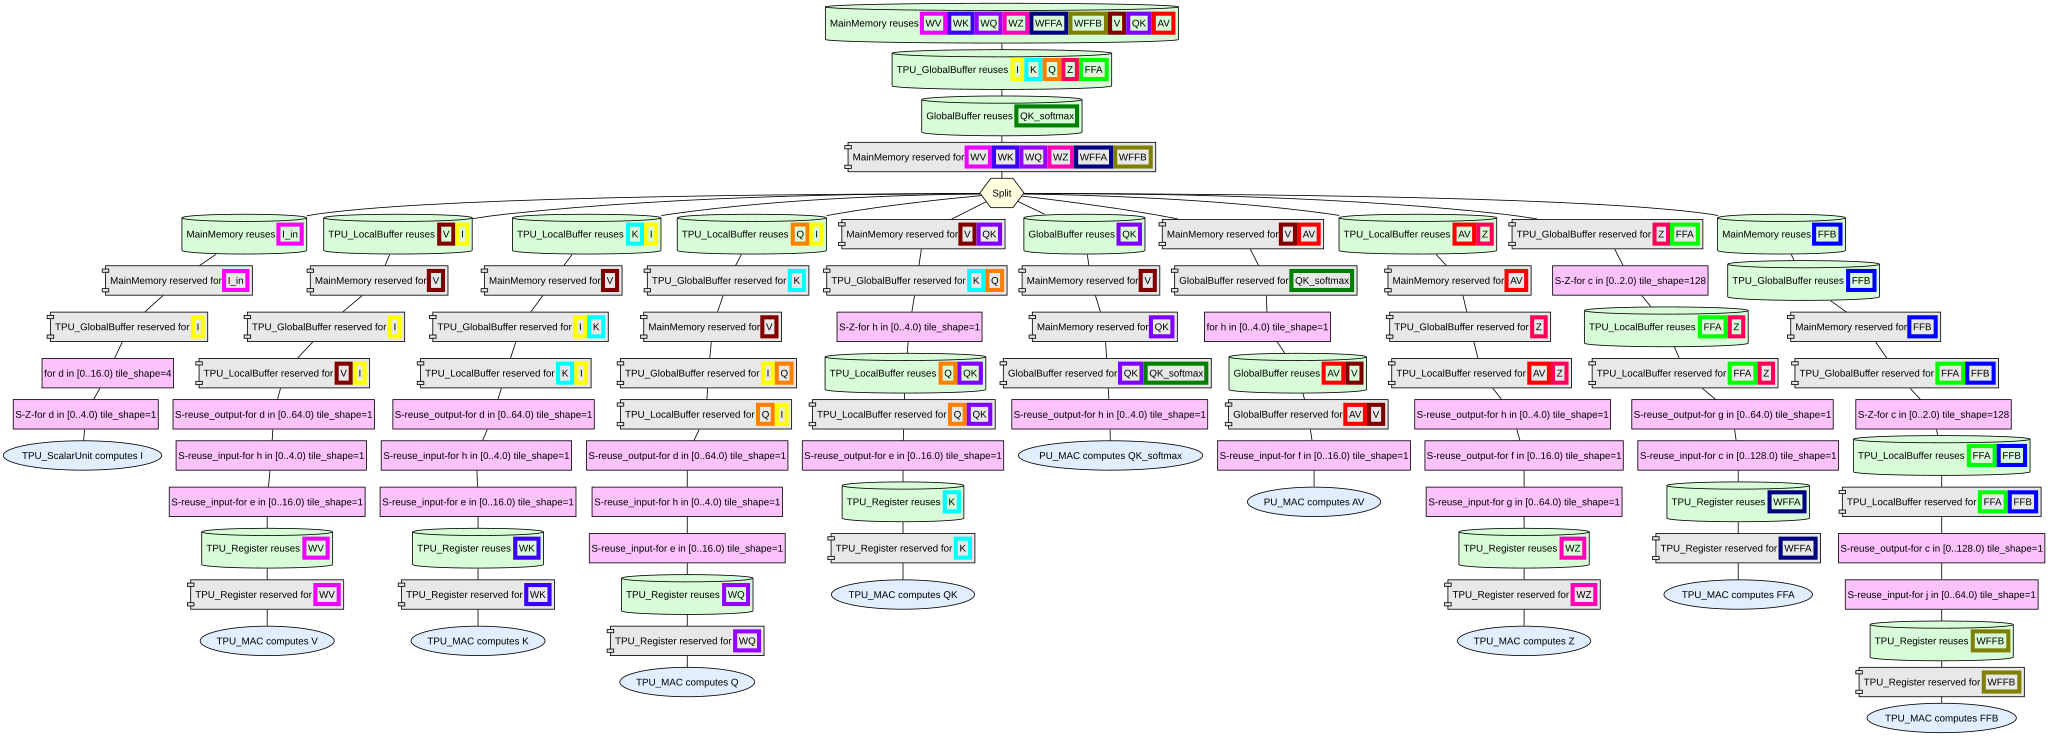

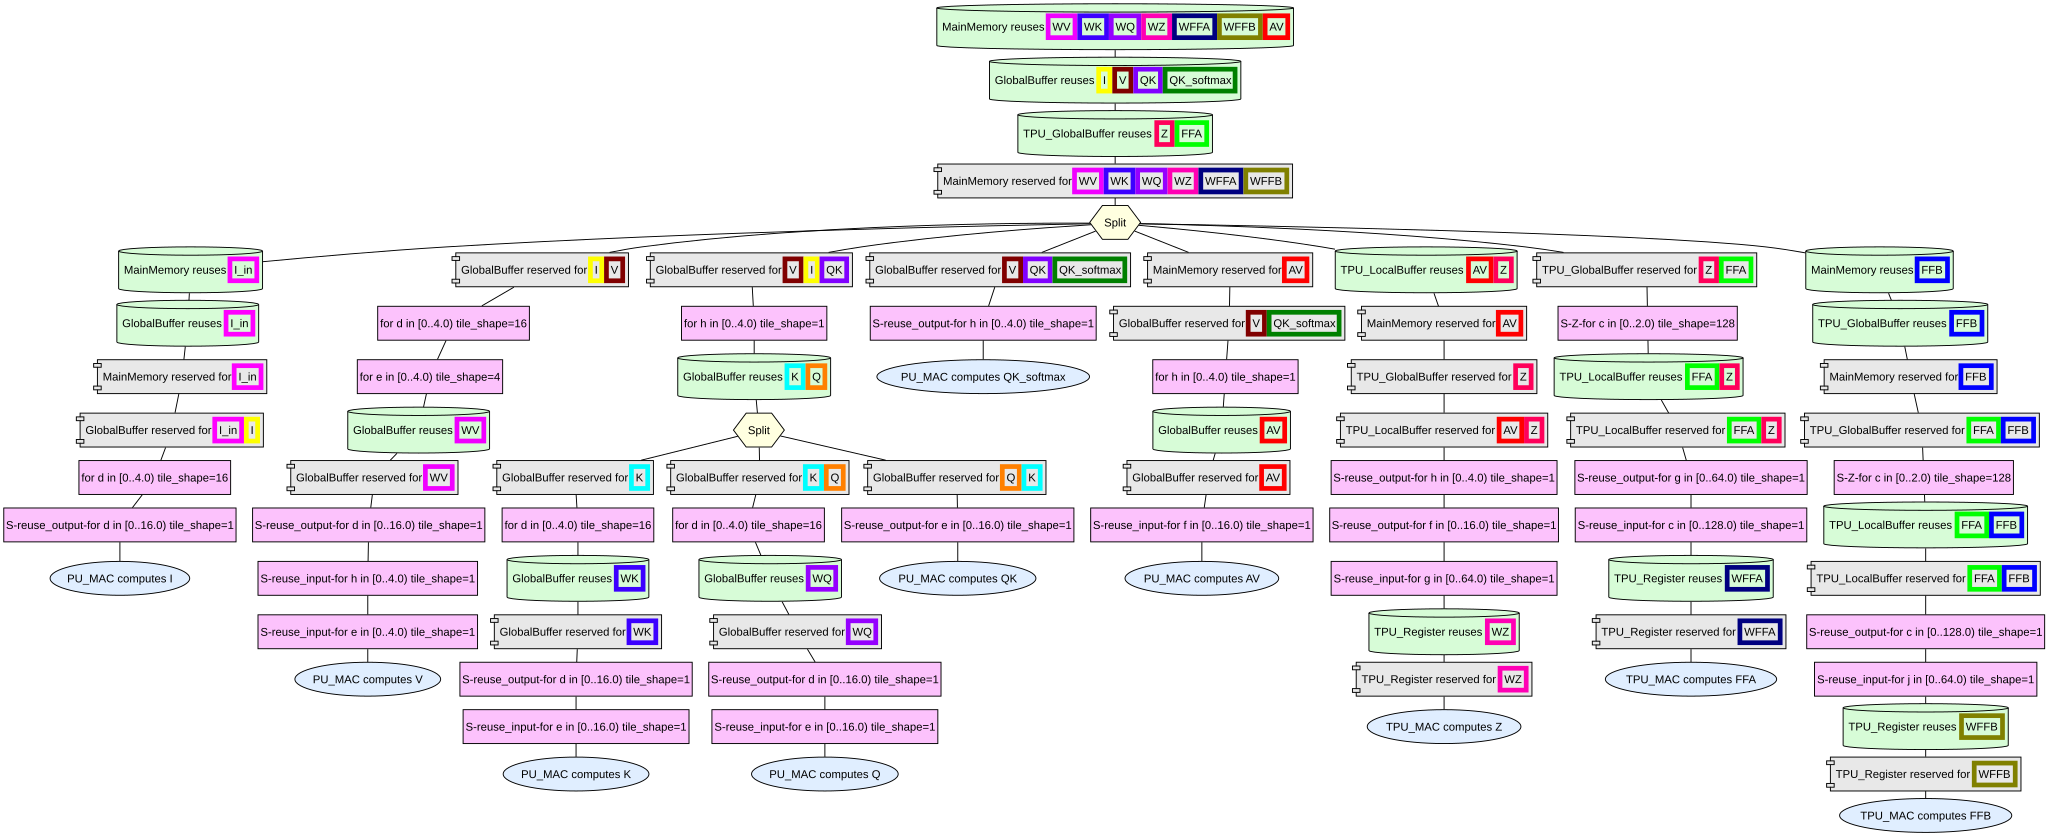

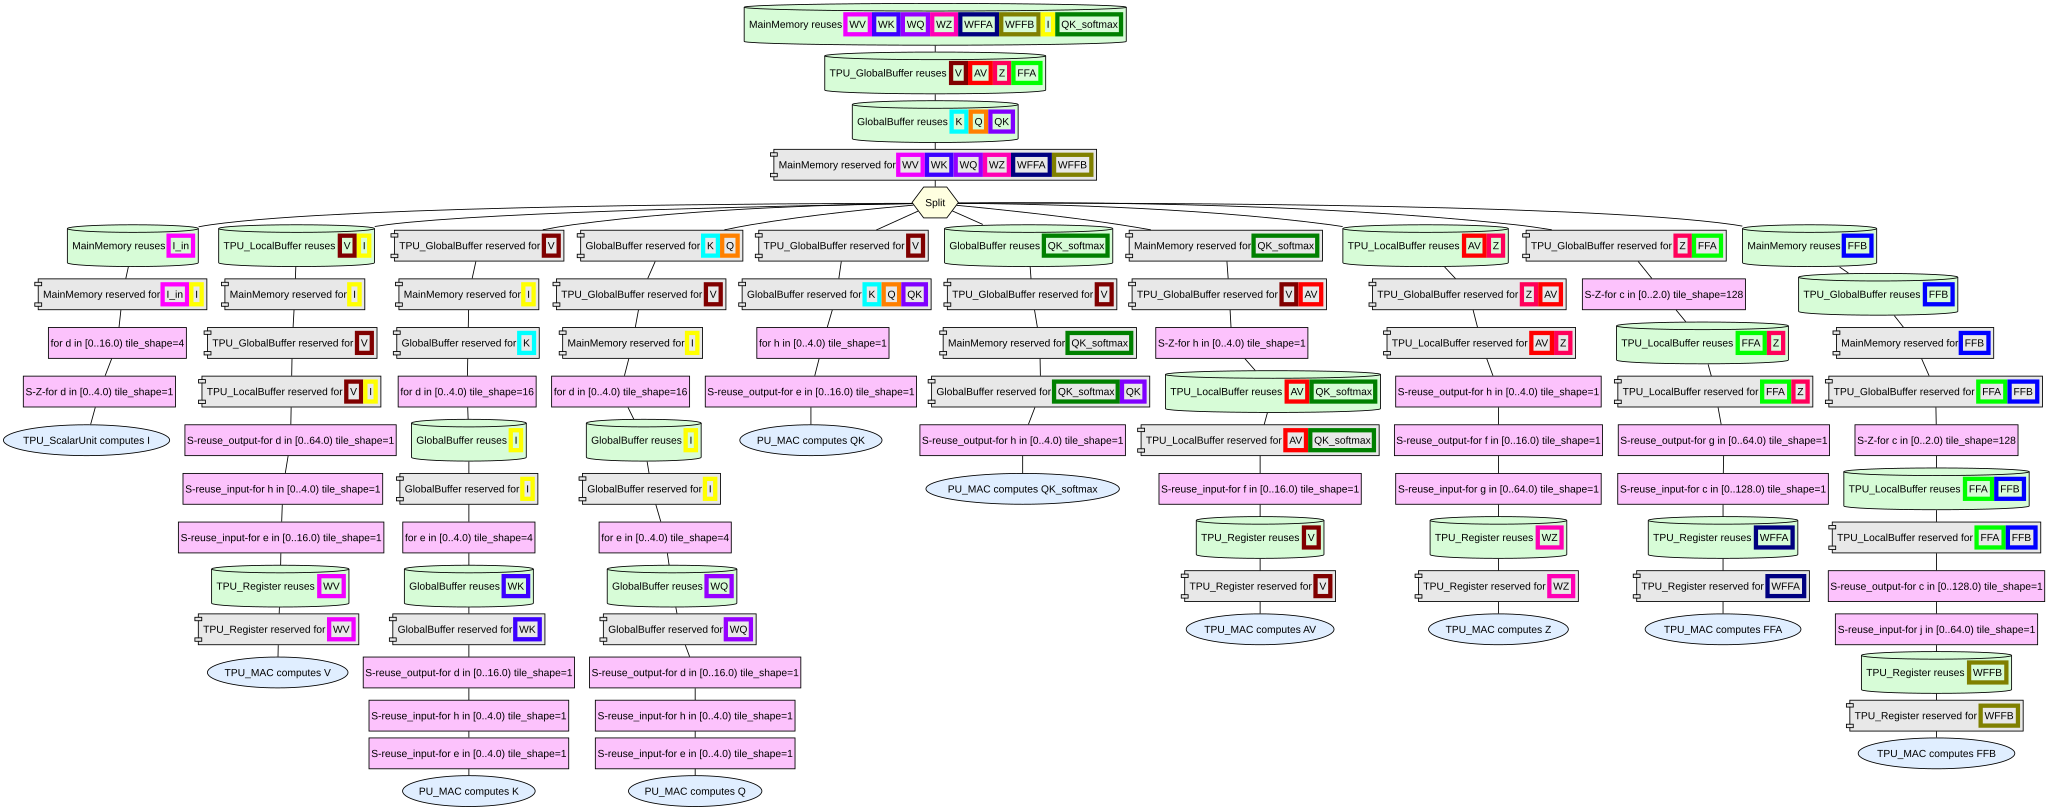

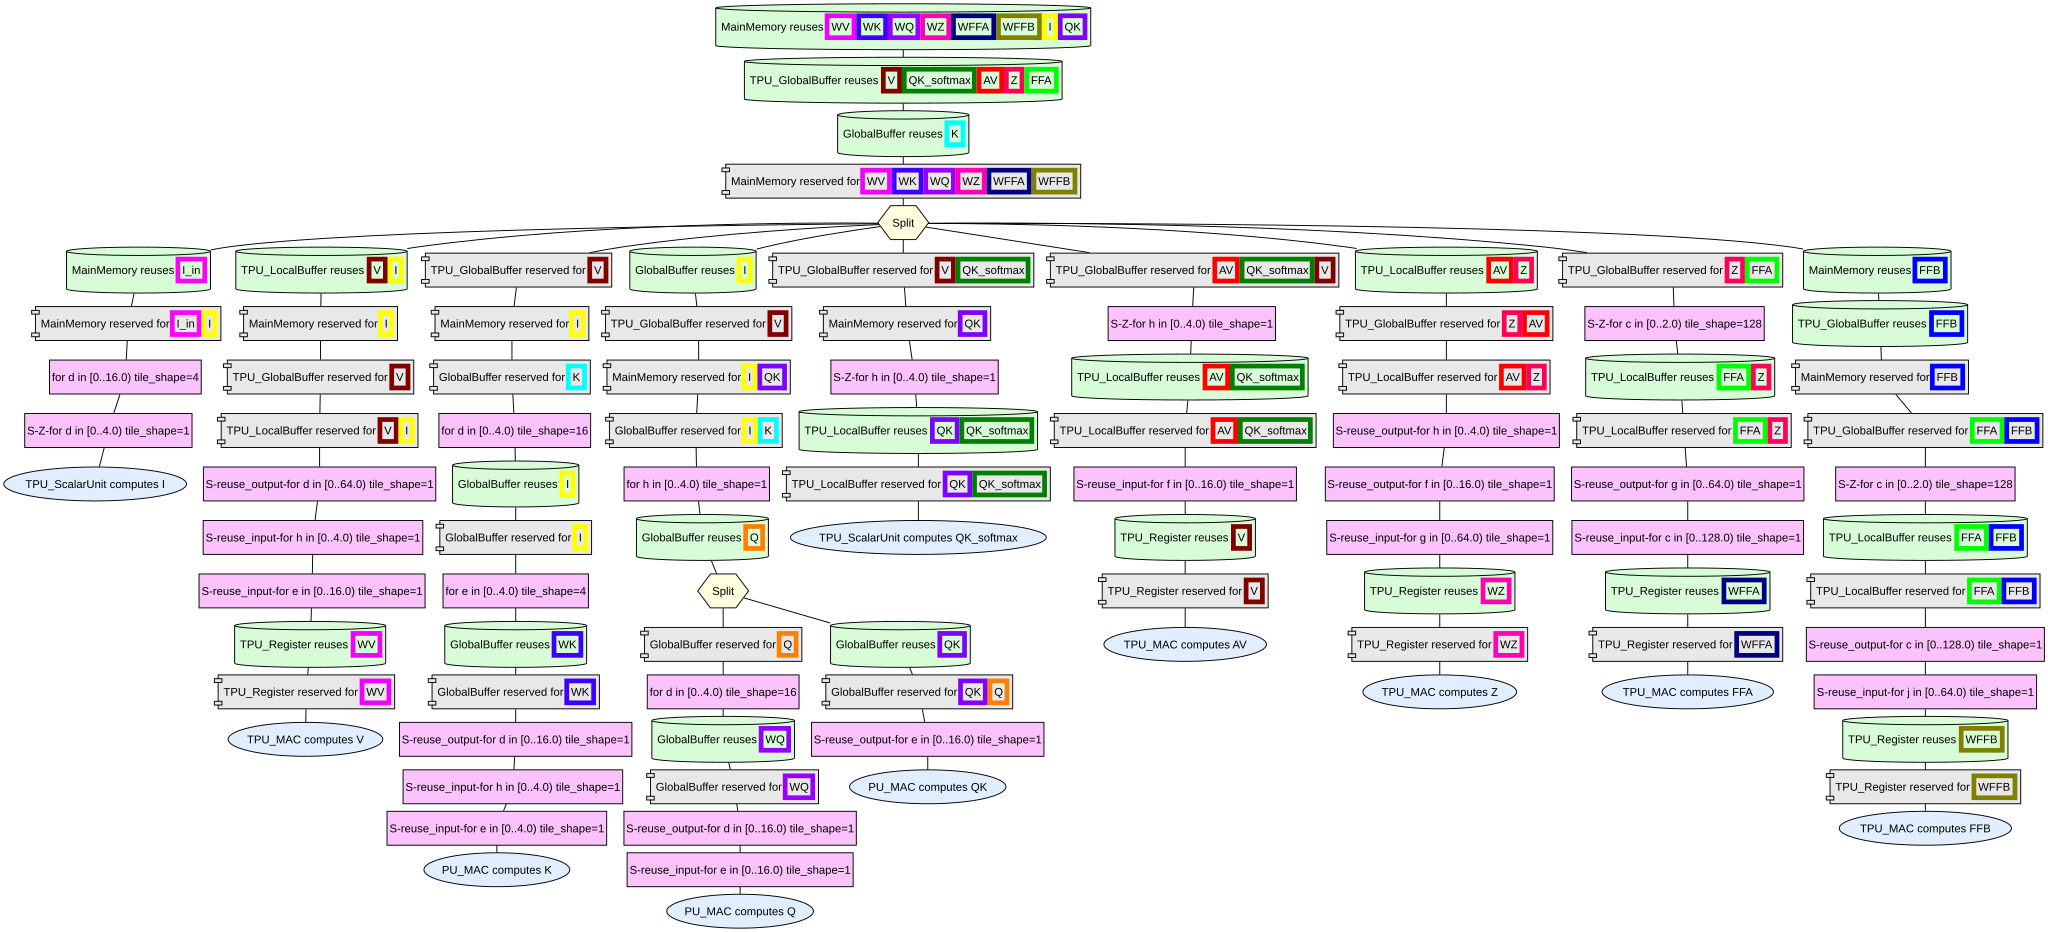

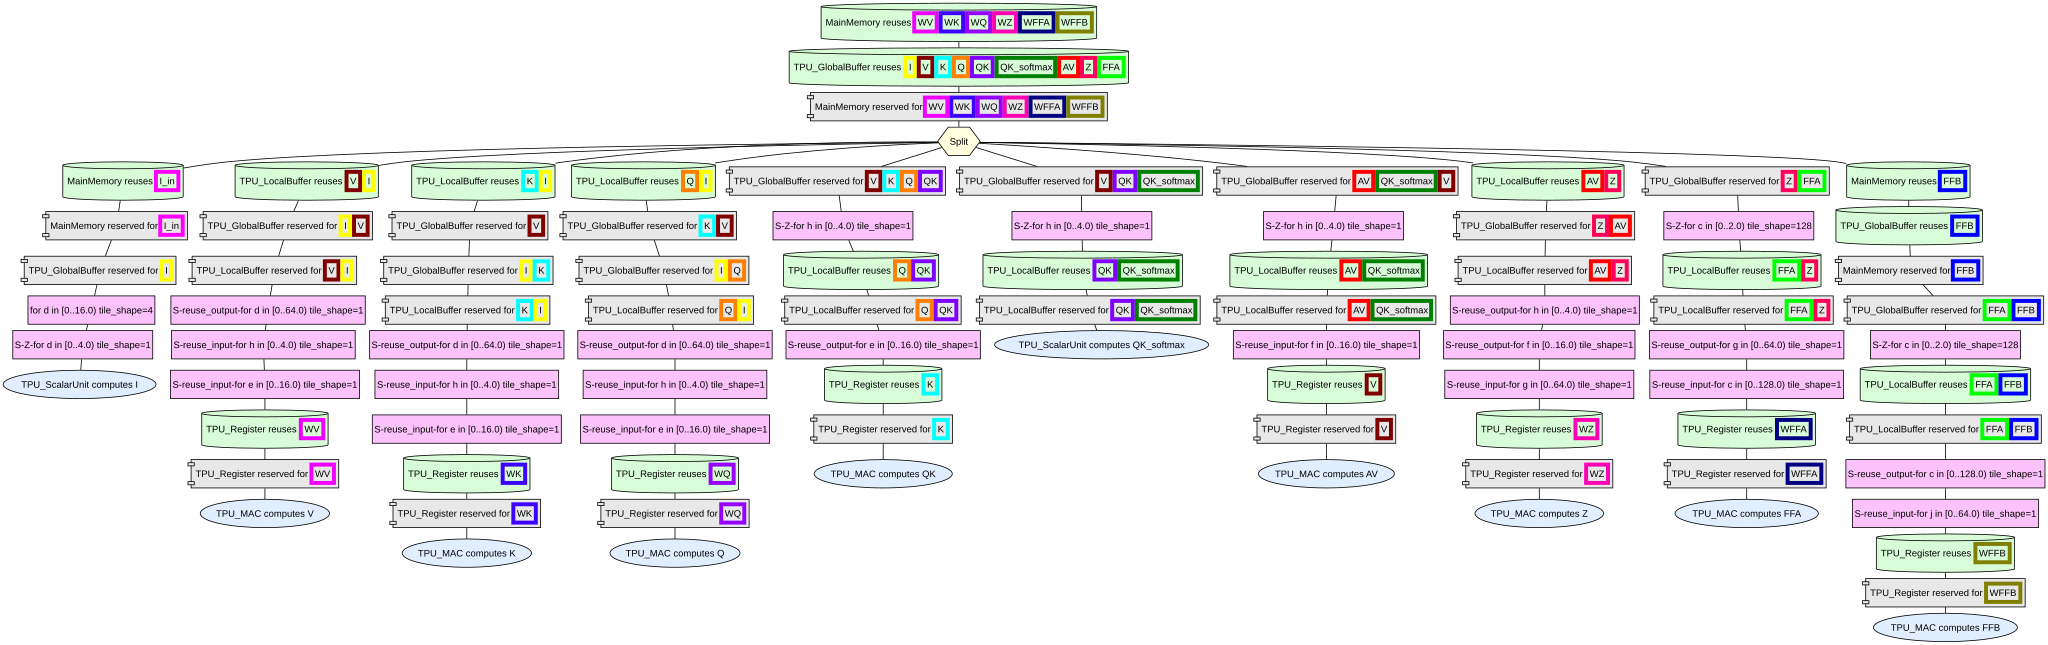

In [74]:

from IPython.display import display

for i in range(len(mapping)):
    display(mapping[i].render())

## Results

Helper to pick a single result when the mapper returns a Pareto set (list of
optimal trade-offs). We select the point with minimum latency.

In [ ]:
def pick(val, idx=None):
    """If val is a list (Pareto set), pick element at idx (default: 0)."""
    if isinstance(val, list):
        return val[idx if idx is not None else 0]
    return val


def best_latency_idx(result):
    """Return index of Pareto point with minimum latency, or None if scalar."""
    lat = result.latency()
    if isinstance(lat, list):
        return min(range(len(lat)), key=lambda i: lat[i])
    return None


idx = best_latency_idx(mapping)
print(idx)
energy = pick(mapping.energy(), idx)
latency = pick(mapping.latency(), idx)

print(f"Energy:  {energy:.6e} J")
print(f"Latency: {latency:.6e} s ({latency * 1e6:.2f} us)")

Energy:  5.807789e-06 J
Latency: 1.607035e-07 s (0.16 us)


### Per-Component Energy and Latency

This shows which hardware components dominate energy and latency. Components prefixed
with `TPU_` belong to the systolic array path; `AiM_BankDRAM`, `GlobalBuffer`, and
`PU_MAC` belong to the AiM path.

In [66]:
energy_by_comp = mapping.energy(per_component=True)
latency_by_comp = mapping.latency(per_component=True)

print(f"{'Component':<25} {'Energy (J)':>14} {'Latency (s)':>14}")
print("-" * 55)
for comp in sorted(energy_by_comp, key=lambda c: -pick(energy_by_comp[c], idx)):
    e = pick(energy_by_comp[comp], idx)
    l = pick(latency_by_comp.get(comp, 0), idx)
    if e > 0 or l > 0:
        print(f"{comp:<25} {e:>14.6e} {l:>14.6e}")

Component                     Energy (J)    Latency (s)
-------------------------------------------------------
MainMemory                  5.544814e-06   1.605733e-07
GlobalBuffer                2.579780e-07   0.000000e+00
PU_MAC                      4.928000e-09   6.281250e-09
TPU_LocalBuffer             6.937600e-11   0.000000e+00
TPU_ScalarUnit              0.000000e+00   7.440476e-12


### Per-Einsum Breakdown

Shows energy and latency for each operation, and which compute path was used.

In [67]:
energy_by_ein = mapping.energy(per_einsum=True)
latency_by_ein = mapping.latency(per_einsum=True)

# Determine which path each einsum uses by checking the mapping string
mapping_col = "Total<SEP>mapping"
has_mapping_col = mapping_col in mapping.data.columns

def detect_path(einsum_name):
    """Detect TPU vs AiM from the mapping string for a given einsum."""
    if has_mapping_col:
        row = mapping.data.iloc[0 if idx is None else idx]
        mapping_str = str(row.get(mapping_col, ""))
        # Check per-einsum mapping columns too
        ein_col = f"{einsum_name}<SEP>mapping"
        if ein_col in mapping.data.columns:
            mapping_str = str(row.get(ein_col, ""))
        if "TPU_MAC" in mapping_str or "TPU_ScalarUnit" in mapping_str:
            return "TPU"
        if "PU_MAC" in mapping_str:
            return "AiM"
    return "?"

print(f"{'Einsum':<15} {'Path':<6} {'Energy (J)':>14} {'Latency (s)':>14}")
print("-" * 55)

tpu_einsums, aim_einsums = [], []
for ein in energy_by_ein:
    e = pick(energy_by_ein[ein], idx)
    l = pick(latency_by_ein.get(ein, 0), idx)
    path = detect_path(ein)
    if path == "TPU":
        tpu_einsums.append(ein)
    elif path == "AiM":
        aim_einsums.append(ein)
    print(f"{ein:<15} {path:<6} {e:>14.6e} {l:>14.6e}")

print(f"\nTPU einsums: {', '.join(tpu_einsums) or 'none'}")
print(f"AiM einsums: {', '.join(aim_einsums) or 'none'}")

Einsum          Path       Energy (J)    Latency (s)
-------------------------------------------------------
I               AiM      7.341056e-09   2.084691e-10
V               AiM      4.825139e-07   1.334202e-08
K               AiM      4.825139e-07   1.334202e-08
Q               AiM      4.825139e-07   1.334202e-08
QK              AiM      7.602560e-10   1.250000e-10
QK_softmax      TPU      9.692160e-10   2.605863e-11
AV              AiM      7.838080e-10   3.125000e-11
Z               AiM      4.825139e-07   1.334202e-08
FFA             AiM      1.930056e-06   5.336808e-08
FFB             AiM      1.937824e-06   5.357655e-08

TPU einsums: QK_softmax
AiM einsums: I, V, K, Q, QK, AV, Z, FFA, FFB


## Visualizations

Energy breakdown by component, stacked by einsum.

(<Figure size 2400x400 with 8 Axes>,
 array([<Axes: title={'center': '0-m0'}, ylabel='Energy (J)'>,
        <Axes: title={'center': 'Nonem1'}>,
        <Axes: title={'center': 'Nonem2'}>,
        <Axes: title={'center': 'Nonem3'}>,
        <Axes: title={'center': 'Nonem4'}>,
        <Axes: title={'center': 'Nonem5'}>,
        <Axes: title={'center': 'Nonem6'}>,
        <Axes: title={'center': 'Nonem7'}>], dtype=object))

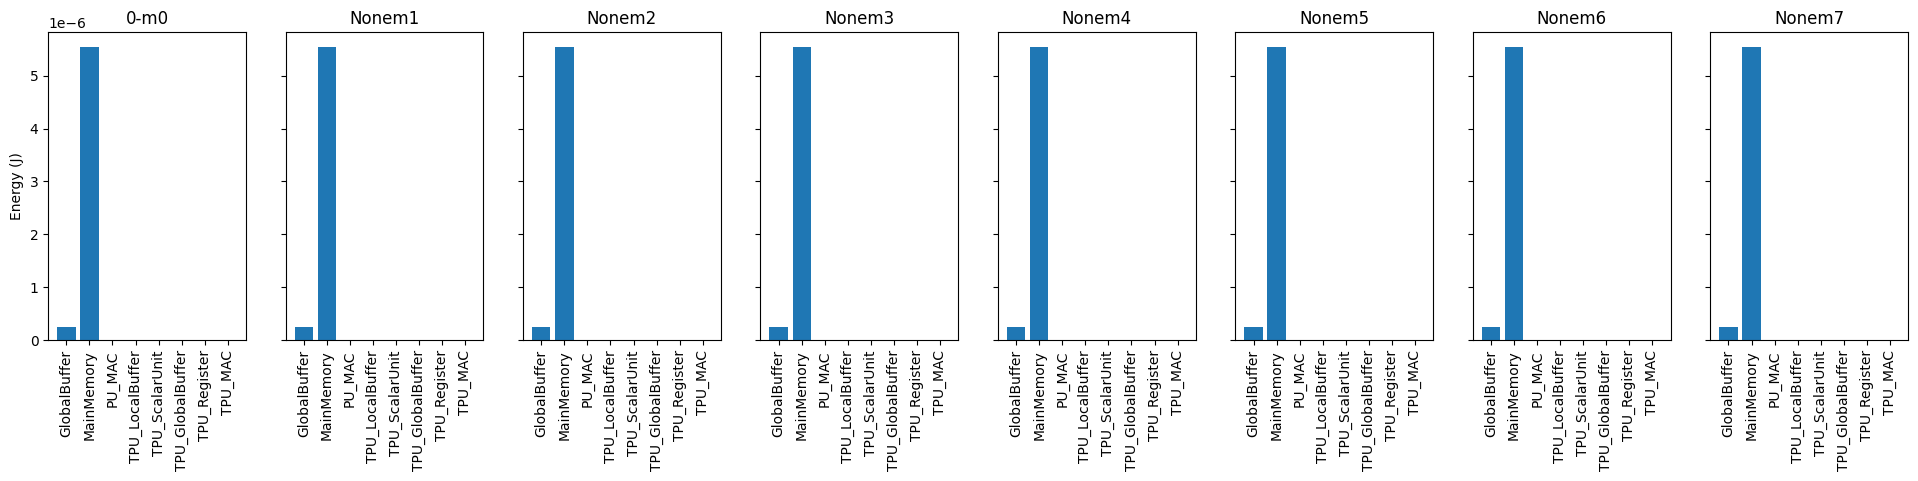

In [68]:
from accelforge.plotting.mappings import plot_energy_breakdown

plot_energy_breakdown([mapping], separate_by=["component"])

(<Figure size 2400x400 with 8 Axes>,
 array([<Axes: title={'center': '0-m0'}, ylabel='Energy (J)'>,
        <Axes: title={'center': 'QK_softmaxm1'}>,
        <Axes: title={'center': 'QK_softmaxm2'}>,
        <Axes: title={'center': 'QK_softmaxm3'}>,
        <Axes: title={'center': 'QK_softmaxm4'}>,
        <Axes: title={'center': 'QK_softmaxm5'}>,
        <Axes: title={'center': 'QK_softmaxm6'}>,
        <Axes: title={'center': 'QK_softmaxm7'}>], dtype=object))

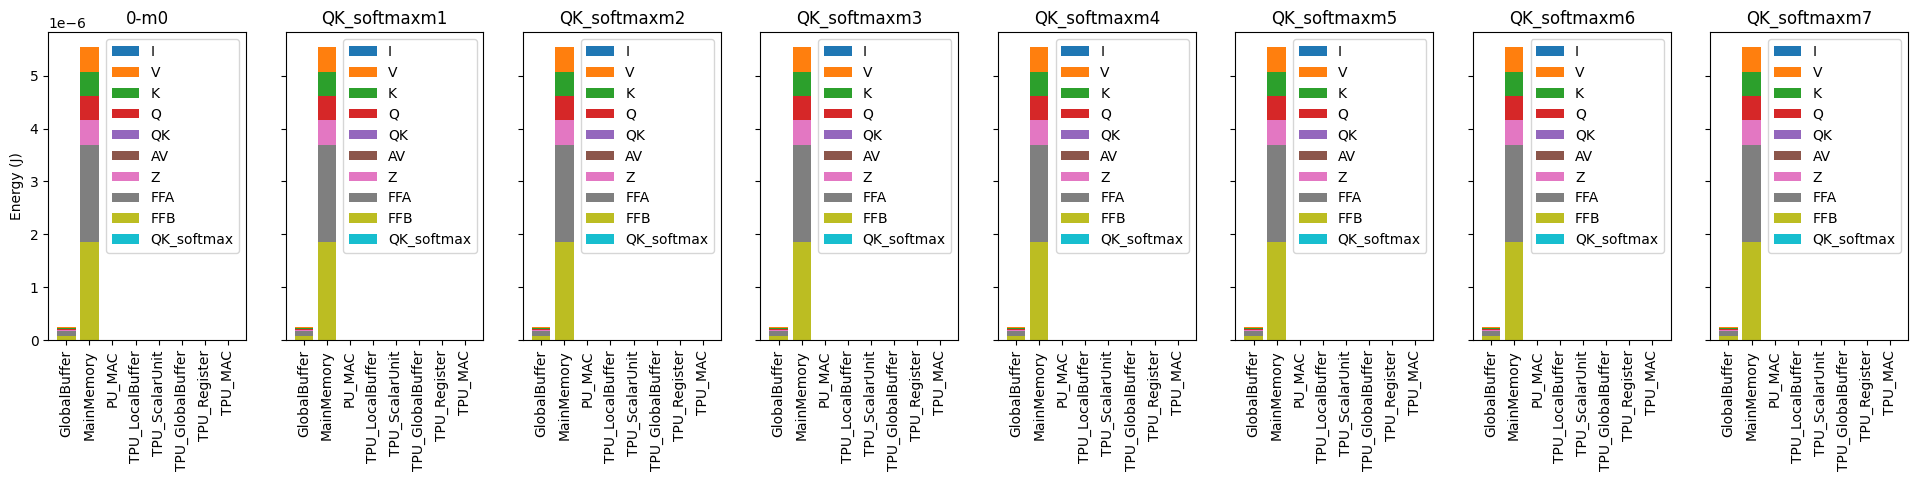

In [69]:
plot_energy_breakdown([mapping], separate_by=["component"], stack_by=["einsum"])

(<Figure size 2400x400 with 8 Axes>,
 array([<Axes: title={'center': '0-m0'}, ylabel='Energy (J)'>,
        <Axes: title={'center': 'Nonem1'}>,
        <Axes: title={'center': 'Nonem2'}>,
        <Axes: title={'center': 'Nonem3'}>,
        <Axes: title={'center': 'Nonem4'}>,
        <Axes: title={'center': 'Nonem5'}>,
        <Axes: title={'center': 'Nonem6'}>,
        <Axes: title={'center': 'Nonem7'}>], dtype=object))

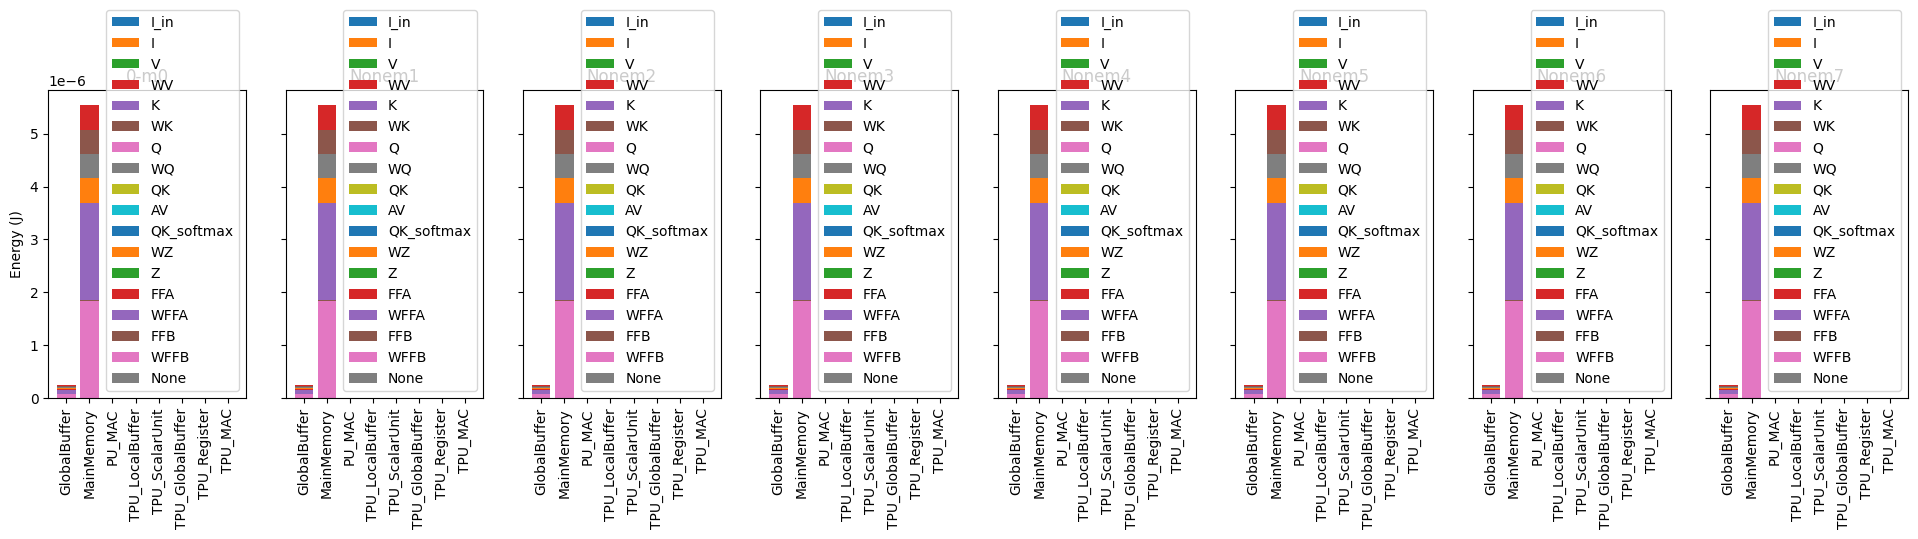

In [70]:
plot_energy_breakdown([mapping], separate_by=["component"], stack_by=["tensor"])

## Decode vs Prefill Comparison

During decode (M=1), operations are memory-bound and should favor AiM.
During prefill (M=128), operations become compute-bound and should favor the TPU.
We compare the two phases by re-mapping with different token counts.

In [71]:
results_by_phase = {}

for phase, tokens in [("Decode (M=1)", 1), ("Prefill (M=128)", 128)]:
    phase_params = {"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": tokens}
    phase_spec = af.Spec.from_yaml(
        HYBRID_ARCH, WORKLOAD, jinja_parse_data=phase_params
    )
    phase_spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
    phase_mapping = phase_spec.map_workload_to_arch()

    phase_idx = best_latency_idx(phase_mapping)
    results_by_phase[phase] = {
        "mapping": phase_mapping,
        "energy": pick(phase_mapping.energy(), phase_idx),
        "latency": pick(phase_mapping.latency(), phase_idx),
    }
    print(f"{phase}: energy={results_by_phase[phase]['energy']:.4e} J, "
          f"latency={results_by_phase[phase]['latency']:.4e} s")











Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 10/10 [00:00<00:00, 61.21it/s]





Generating pmapping templates for compute TPU_ScalarUnit Einsum I: 2it [00:00, 336.42it/s]
Generating pmapping templates for compute TPU_MAC Einsum I: 0it [00:00, ?it/s] ?it/s]
Generating pmapping templates for compute PU_MAC Einsum I: 3it [00:00, 233.03it/s]t/s], ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum V: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum K: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Q: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum AV: 0it [00:00, ?it/s]]
Generating pmapping templates for compute TPU_ScalarUnit Einsum QK: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum FFA: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Z:

Einsum I has 5 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	2	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	3	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	4	[I_in in MainMemory] T-b  T-d  T-m  [I_in in GlobalBuffer] [I in GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
Einsum V has 116 pmapping jobs:
	0	[WV in MainMemory] T-b  T-m  [I in TPU_GlobalBuffer] T-b  T-e  T-h  T-m  [V in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I in TPU_LocalBuffer] T-e  T-h  [V in TPU_LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [W

KeyboardInterrupt: 

In [ ]:
phase_mappings = [v["mapping"] for v in results_by_phase.values()]
phase_labels = list(results_by_phase.keys())

plot_energy_breakdown(
    phase_mappings,
    separate_by=["component"],
    stack_by=["einsum"],
    labels=phase_labels,
)